In [3]:
#supress tensorflow log printing
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [4]:
import pandas as pd
from IPython.display import display
import time
import numpy as np
import tools
import misc_tools
from matplotlib import pyplot as plt
import tensorflow as tf
import scipy.stats
%load_ext autoreload
%autoreload 2
sims = "sims"
models_file = "../models/trained_chiTest4/"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#loading data
data = tools.create_simulated_data.txt_file_split_to_npy("../data/simCatalog_three_pix_triout_chiTest4.txt", seed = 31)
x_train, y_train, x_val, y_val, x_test, y_test = data[sims]

#### Simple multi output model <a class="anchor" id="NSOM"></a>

RAM usage in GB: 0.136402313
Parameter numbers: 8841
Zero parameters: 0.0


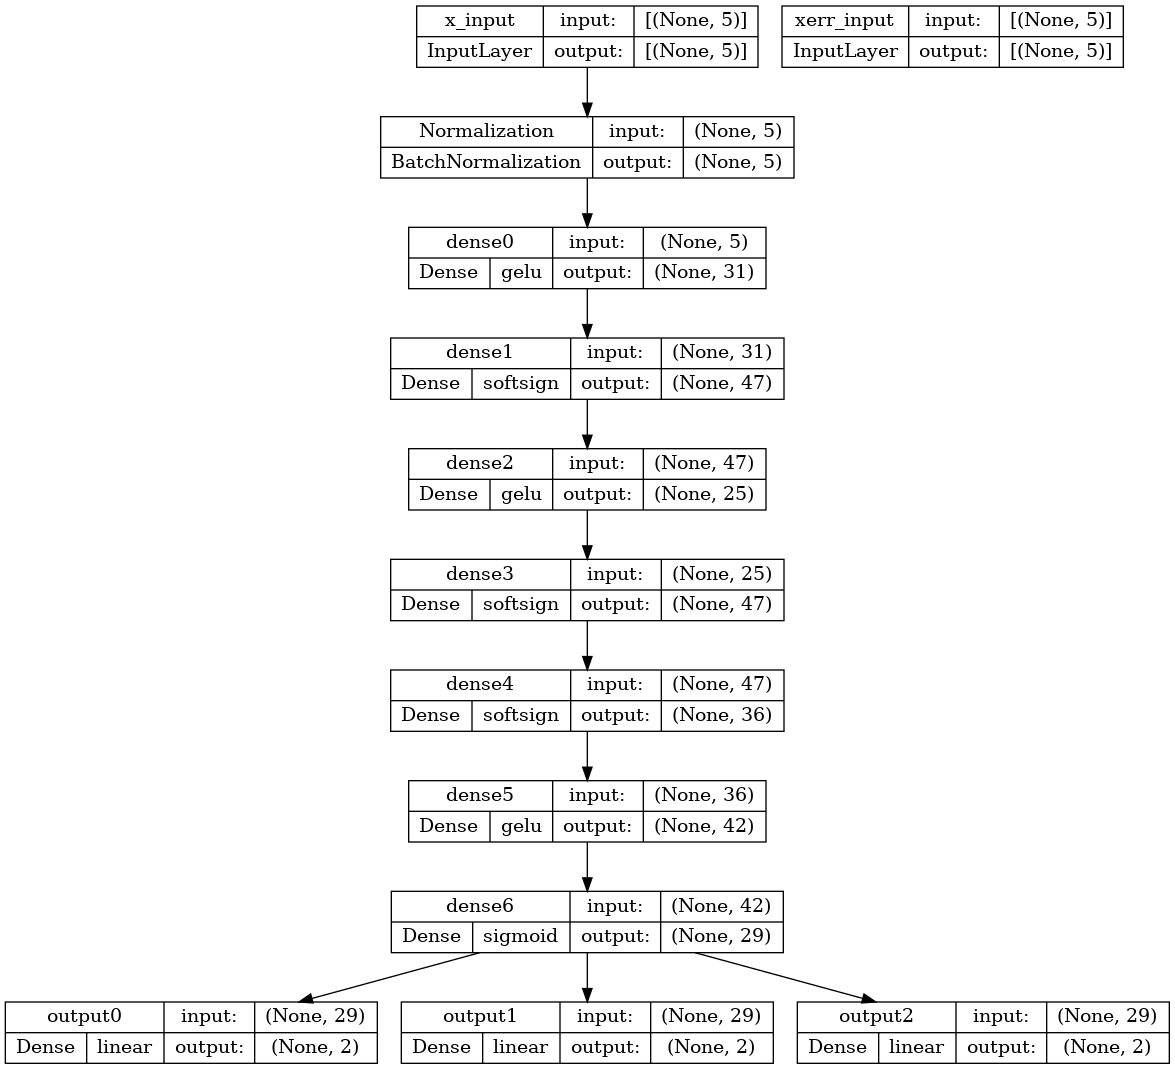

In [6]:
model = tf.keras.models.load_model(models_file + "photozannv10p_trained", compile=False)
os.makedirs("./IMAGES/SimpleMulti/", exist_ok=True)
img_path = "./IMAGES/SimpleMulti/"
model_usage = tools.create_model.model_memory_usage(model, batch_size=x_test[0].shape[0])
param_nums, zero_params = tools.create_model.model_parameter_num(model)
print("RAM usage in GB:", model_usage / 1e9)
print("Parameter numbers:", param_nums)
print("Zero parameters:", zero_params)

tf.keras.utils.plot_model(model, to_file=img_path+"model.png" ,show_shapes=True, show_layer_activations=True, show_layer_names=True, expand_nested=True)

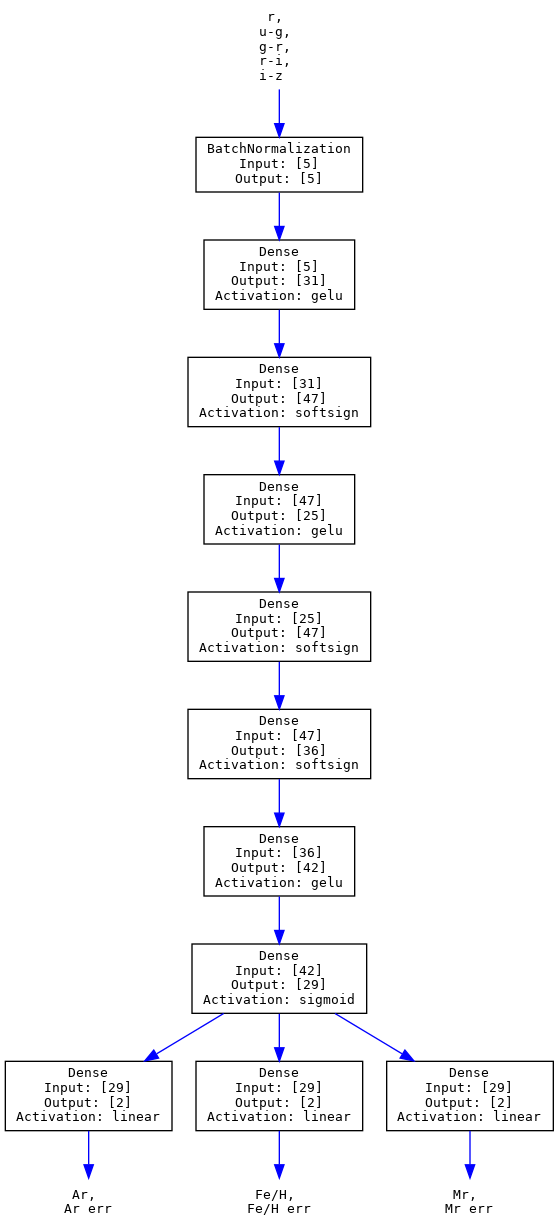

In [7]:
pydot_graph = misc_tools.plotModel (model, ["r, \nu-g, \ng-r, \nr-i, \ni-z  "], ["Ar, \nAr err", "Fe/H, \nFe/H err", "Mr, \nMr err"])
misc_tools.view_pydot(pydot_graph)
pydot_graph.write_png(img_path+"model.png")

In [8]:
start_time = time.time()
prediction = model (x_test)
sigma_p = ([np.abs(np.array(prediction[i])).reshape((-1,2))[:, -1:] for i in range (len(prediction))]) #cleaning shapes of the sigma outputs
p = tuple ([np.array(prediction[i]).reshape((-1,2))[:, :1] for i in range (len(prediction))]) #cleaning shapes of the outputs
print ("Time taken for "+str(p[0].shape[0])+" predictions :", time.time()-start_time, "seconds")
print ("Mean corelation of this model is:", np.array([np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1] for i in range(len(p))]).mean())

Time taken for 122656 predictions : 0.16303634643554688 seconds
Mean corelation of this model is: 0.9023669080263651


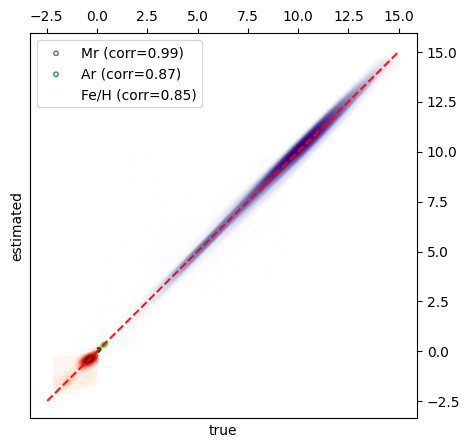

In [9]:
fig, ax = plt.subplots(figsize=(5,5))
fig.set_facecolor('white')
name=["Mr", "Ar", "Fe/H"]
for i in range (len(name)):
    name[i] = name[i]+" (corr="+str(round (np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1], 2))+")"
tools.eval_tools.plot_correlation(y_test, p, ax, name=name, small_size =200)
plt.savefig(img_path+"All_correlation.png",bbox_inches='tight')
plt.show()

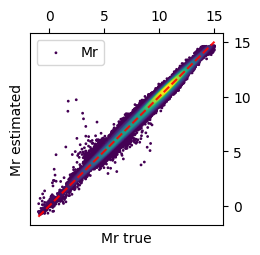

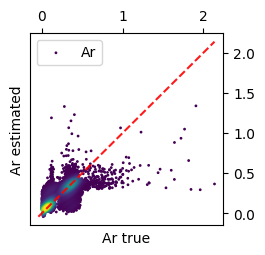

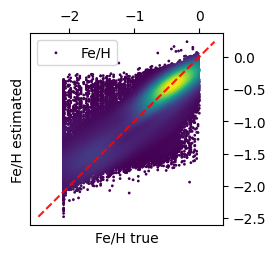

In [10]:
names=["Mr", "Ar", "Fe/H"]
#fig, ax = plt.subplots(len(names), figsize=(5,len(names)*5))
#fig.set_facecolor('white')
for i in range (len(names)):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    fig.set_facecolor('white')
    name = names[i]
    ax=tools.eval_tools.plot_correlation(y_test[i], p[i], ax, name=name, small_size=200)
    fig.savefig(img_path+name.replace("/","")+"_correlation.png", bbox_inches='tight')
    plt.show()

$\mu$($Ar_{e} - Ar_{t}$)=0.01
$\sigma$($Ar_{e} - Ar_{t}$)=0.05
$\mu$($Mr_{e} - Mr_{t}$)=-0.01
$\sigma$($Mr_{e} - Mr_{t}$)=0.21
$\mu$($Fe/H_{e} - Fe/H_{t}$)=-0.01
$\sigma$($Fe/H_{e} - Fe/H_{t}$)=0.18


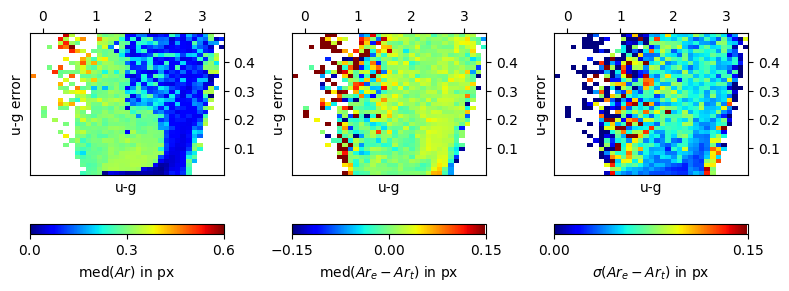

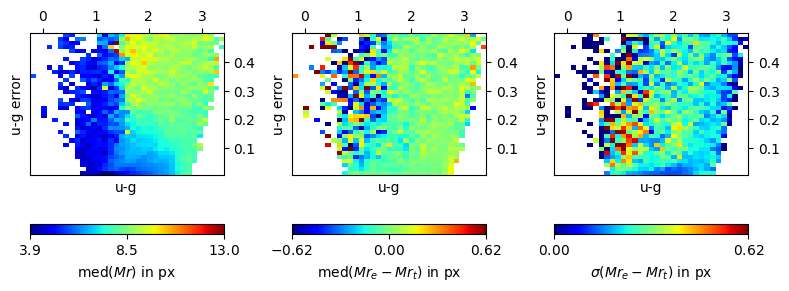

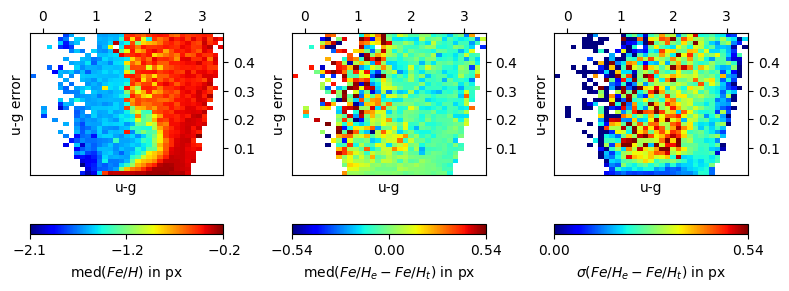

In [11]:
Mrsample_true, Arsample_true, FeHsample_true = (y_test[i][:,0] for i in range (len(y_test)))

r_magSample, ugSample, grSample, riSample, izSample = (x_test[0][:,i] for i in range (x_test[0].shape[1]))
r_magErrSample, ugErrSample, grErrSample, riErrSample, izErrSample = (x_test[1][:,i] for i in range (x_test[1].shape[1]))
Mrsample, Arsample, FeHsample = tuple ([np.array(p[i]).reshape((-1)) for i in range (len(p))]) #cleaning shapes of the outputs
figar = misc_tools.pike_plot_multiple(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Arsample_true[ugErrSample<0.5], value_name="Ar")
figar.savefig(img_path+"Ar_pike.png", bbox_inches='tight')
figmr = misc_tools.pike_plot_multiple(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Mrsample_true[ugErrSample<0.5], value_name="Mr")
figmr.savefig(img_path+"Mr_pike.png", bbox_inches='tight')
figfeh = misc_tools.pike_plot_multiple(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           FeHsample_true[ugErrSample<0.5], value_name="Fe/H")
figfeh.savefig(img_path+"FeH_pike.png", bbox_inches='tight')

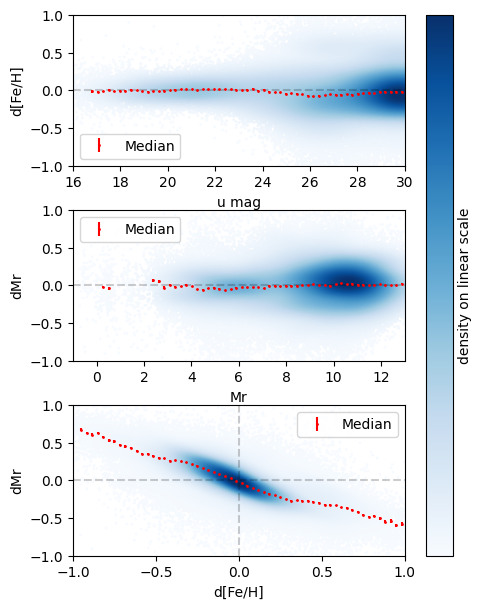

In [12]:
_ = misc_tools.plot_2D_multiple (x_test, p, y_test)
plt.savefig(img_path+"bias.png", bbox_inches='tight')

Histograms of estimated sigma


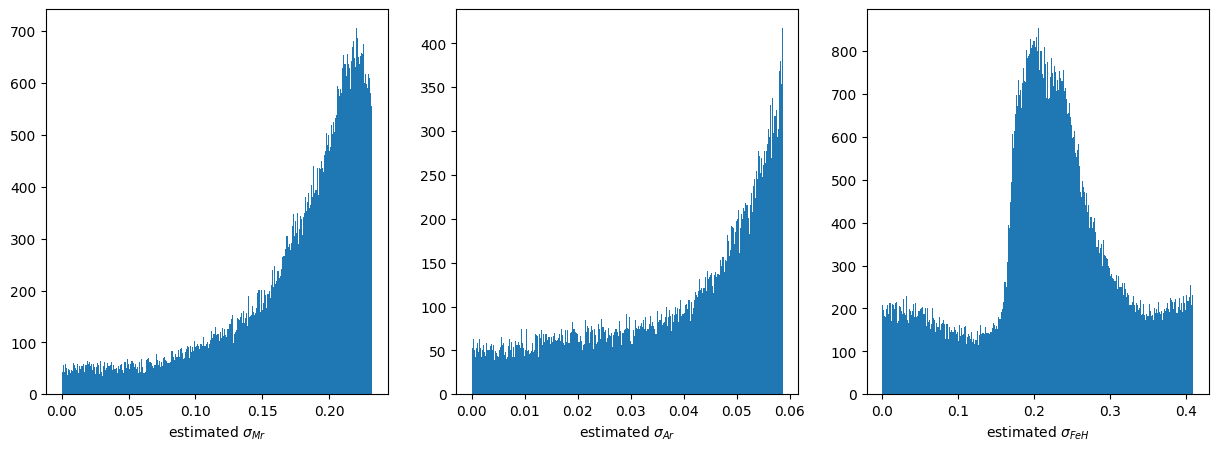

In [13]:
print ("Histograms of estimated sigma")
fig, ax = plt.subplots(1, 3, figsize=(3*5,5))
outputs = ["Mr", "Ar", "FeH"]
for i, name in enumerate(outputs):
    ax[i] = misc_tools.plot_sigma_histogram (ax[i], sigma_p[i], (sigma_p[i].min(), sigma_p[i].min()+3*tools.eval_tools.sigGzi(sigma_p[i])), name)

Histograms of expected N(0,1)


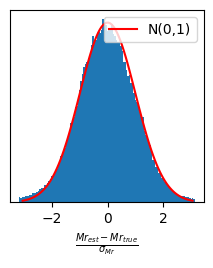

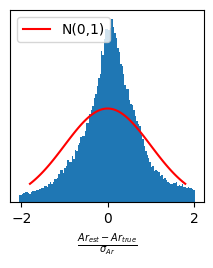

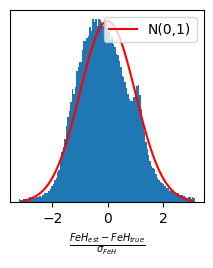

In [14]:
print ("Histograms of expected N(0,1)")
ax_1=[]
fig_1=[]
for i in range (3):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    ax_1.append(ax)
    fig_1.append(fig)
fig = misc_tools.plot_expected_gauss(p, sigma_p, y_test, outputs, ax_1, nbins=120)
names=["Mr", "Ar", "Fe/H"]
for i,fig in enumerate(fig_1):
    fig.savefig(img_path+names[i].replace("/","")+"_gauss.png", bbox_inches='tight')

In [15]:
mse = tf.keras.losses.MeanSquaredError()(y_test, p).numpy()

differences_sigma = [np.abs(y_test[i] - p[i])<sigma_p[i] for i in range (len (p))]
inside_sigma = [differences_sigma[i].sum() for i in range (len (p))]
inside_sigma.append(np.array (differences_sigma).all (axis=0).sum())
inside_sigma = np.array(inside_sigma) / p[0].shape[0]

differences_sigma_mse = [np.abs(y_test[i] - p[i])<sigma_p[i]+mse for i in range (len (p))]
inside_sigma_mse = [differences_sigma_mse[i].sum() for i in range (len (p))]
inside_sigma_mse.append(np.array (differences_sigma_mse).all (axis=0).sum())
inside_sigma_mse = np.array(inside_sigma_mse) / p[0].shape[0]

table = pd.DataFrame([inside_sigma, inside_sigma_mse], columns=["Mr (expect 0.68)", "Ar (expect 0.68)", "Fe/H (expect 0.68)", "All (expect 0.32)"],
                          index=["Percent inside est sigma", "Percent inside (est sigma + MSE)"])
print ("Table of coverage:")
display(table)

Table of coverage:


,Mr (expect 0.68),Ar (expect 0.68),Fe/H (expect 0.68),All (expect 0.32)
Percent inside est sigma,0.653935,0.762670,0.649328,0.423974
Percent inside (est sigma + MSE),0.767423,0.916082,0.783720,0.631954


/mnt/Storage/Projects/BEAST_LSST/Results/misc_tools.py:131: RuntimeWarning: invalid value encountered in scalar divide
  coverage = np.array([(np.abs(y_test[i][(y_test[i] >= bins[j]) & (y_test[i] <= bins[j + 1])] - p[i][


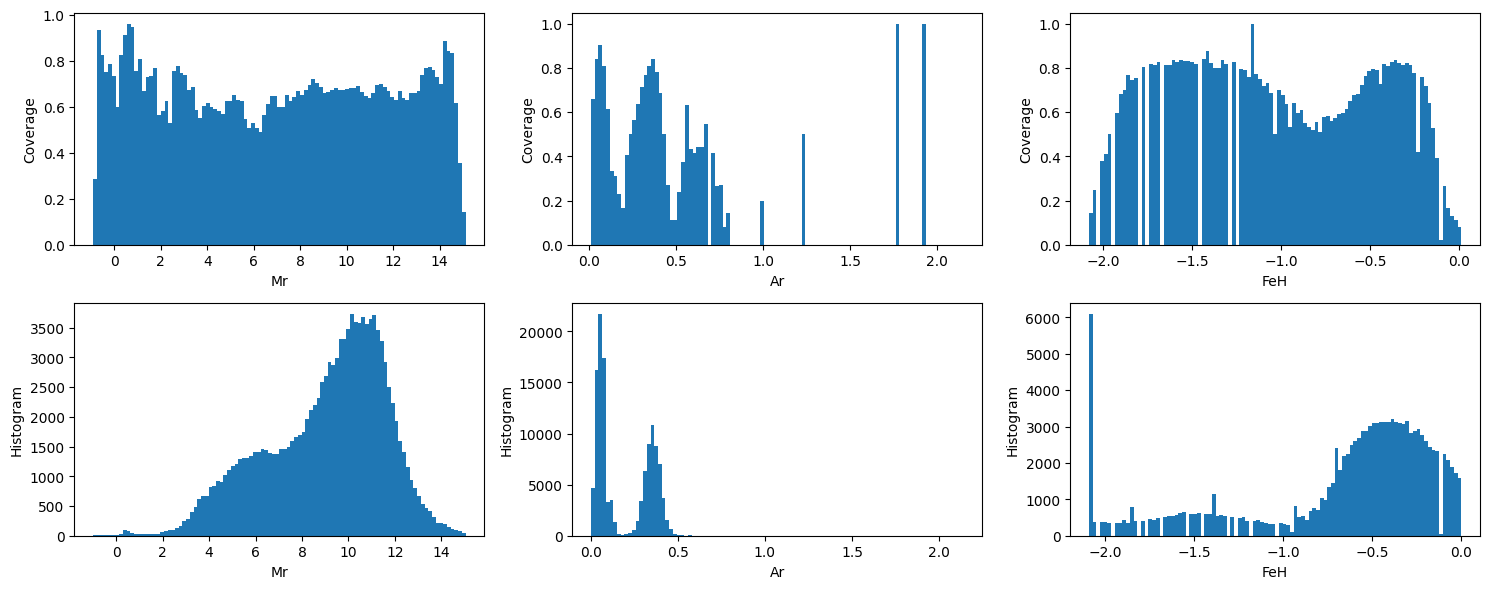

In [16]:
_ = misc_tools.plot_sigma_dependency(p, sigma_p, y_test)

#### Probabilistic multi output model <a class="anchor" id="NSOM"></a>


RAM usage in GB: 0.11628529
Parameter numbers: 7402
Zero parameters: 0.0


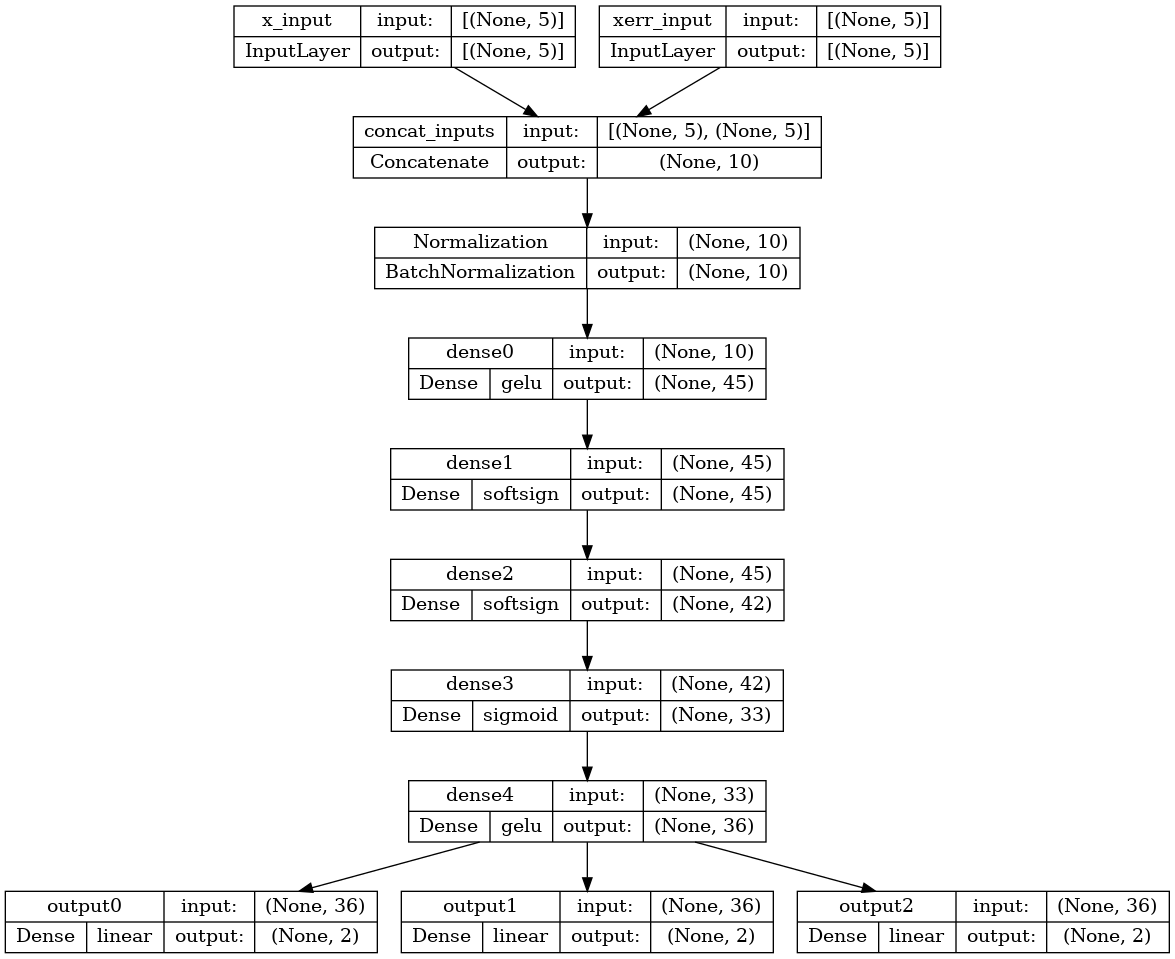

In [17]:
model = tf.keras.models.load_model(models_file + "photozannv20p_trained", compile=False)
os.makedirs("./IMAGES/ProbabilisticMulti/", exist_ok=True)
img_path = "./IMAGES/ProbabilisticMulti/"
model_usage = tools.create_model.model_memory_usage(model, batch_size=x_test[0].shape[0])
param_nums, zero_params = tools.create_model.model_parameter_num(model)
print("RAM usage in GB:", model_usage / 1e9)
print("Parameter numbers:", param_nums)
print("Zero parameters:", zero_params)

tf.keras.utils.plot_model(model, to_file=img_path+"model.png" ,show_shapes=True, show_layer_activations=True, show_layer_names=True, expand_nested=True)

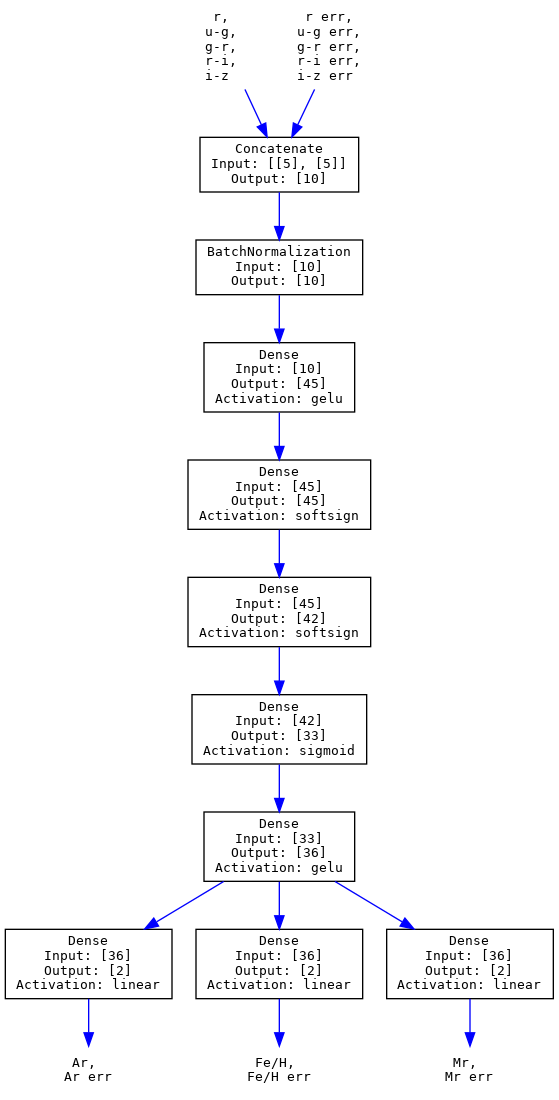

In [18]:
pydot_graph = misc_tools.plotModel (model, ["r, \nu-g, \ng-r, \nr-i, \ni-z  ", "r err, \nu-g err, \ng-r err, \nr-i err, \ni-z err  "], ["Ar, \nAr err", "Fe/H, \nFe/H err", "Mr, \nMr err"])
misc_tools.view_pydot(pydot_graph)
pydot_graph.write_png(img_path+"model.png")

In [19]:
start_time = time.time()
prediction = model (x_test)
sigma_p = ([np.abs(np.array(prediction[i])).reshape((-1,2))[:, -1:] for i in range (len(prediction))]) #cleaning shapes of the sigma outputs
p = tuple ([np.array(prediction[i]).reshape((-1,2))[:, :1] for i in range (len(prediction))]) #cleaning shapes of the outputs
print ("Time taken for "+str(p[0].shape[0])+" predictions :", time.time()-start_time, "seconds")
print ("Mean corelation of this model is:", np.array([np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1] for i in range(len(p))]).mean())

Time taken for 122656 predictions : 0.12863850593566895 seconds
Mean corelation of this model is: 0.8895853865607953


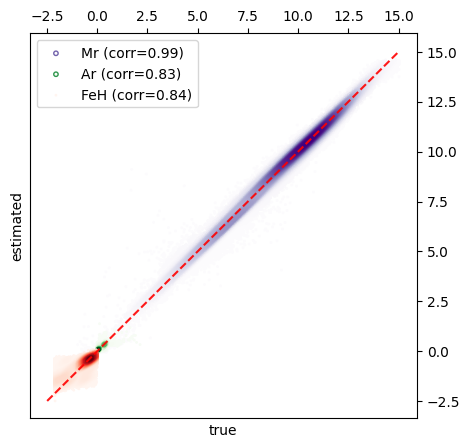

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
fig.set_facecolor('white')
name=["Mr", "Ar", "FeH"]
for i in range (len(name)):
    name[i] = name[i]+" (corr="+str(round (np.corrcoef (y_test[i][:,0], p[i][:, 0]) [0,1], 2))+")"
tools.eval_tools.plot_correlation(y_test, p, ax, name=name, small_size =200)
plt.savefig(img_path+"All_correlation.png", bbox_inches='tight')
plt.show()

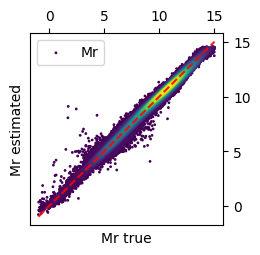

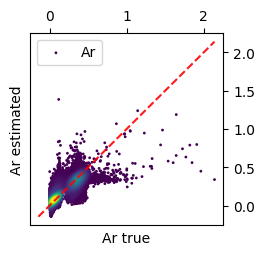

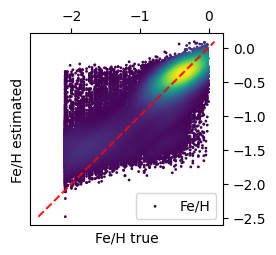

In [21]:
names=["Mr", "Ar", "Fe/H"]
#fig, ax = plt.subplots(len(names), figsize=(5,len(names)*5))
#fig.set_facecolor('white')
for i in range (len(names)):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    fig.set_facecolor('white')
    name = names[i]
    ax=tools.eval_tools.plot_correlation(y_test[i], p[i], ax, name=name, small_size=200)
    fig.savefig(img_path+name.replace("/","")+"_correlation.png", bbox_inches='tight')
    plt.show()

$\mu$($Ar_{e} - Ar_{t}$)=-0.0
$\sigma$($Ar_{e} - Ar_{t}$)=0.07
$\mu$($Mr_{e} - Mr_{t}$)=-0.01
$\sigma$($Mr_{e} - Mr_{t}$)=0.25
$\mu$($Fe/H_{e} - Fe/H_{t}$)=-0.0
$\sigma$($Fe/H_{e} - Fe/H_{t}$)=0.2


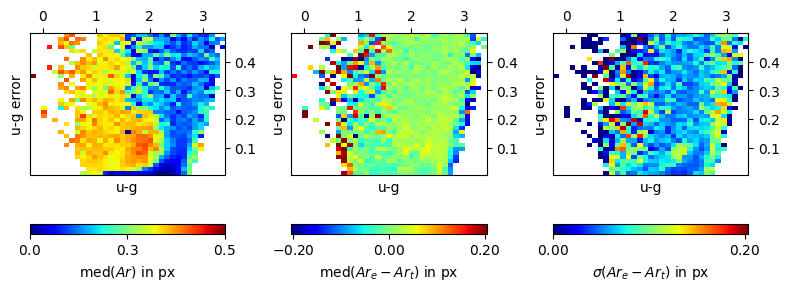

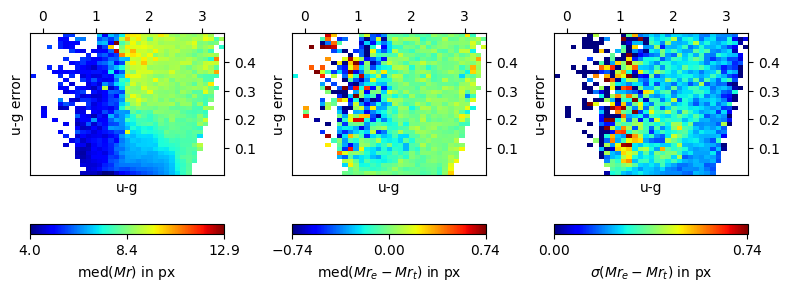

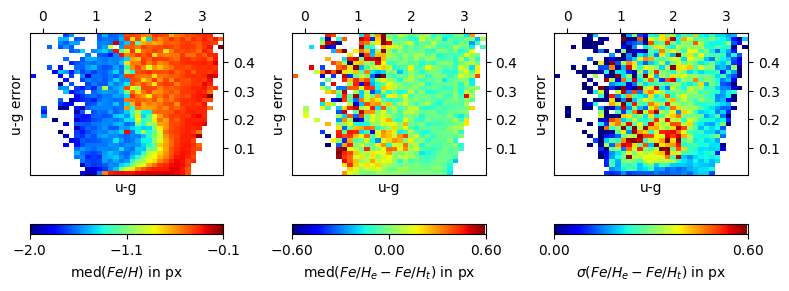

In [22]:
Mrsample_true, Arsample_true, FeHsample_true = (y_test[i][:,0] for i in range (len(y_test)))

r_magSample, ugSample, grSample, riSample, izSample = (x_test[0][:,i] for i in range (x_test[0].shape[1]))
r_magErrSample, ugErrSample, grErrSample, riErrSample, izErrSample = (x_test[1][:,i] for i in range (x_test[1].shape[1]))
Mrsample, Arsample, FeHsample = tuple ([np.array(p[i]).reshape((-1)) for i in range (len(p))]) #cleaning shapes of the outputs
figar = misc_tools.pike_plot_multiple(Arsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Arsample_true[ugErrSample<0.5], value_name="Ar")
figar.savefig(img_path+"Ar_pike.png", bbox_inches='tight')
figmr = misc_tools.pike_plot_multiple(Mrsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           Mrsample_true[ugErrSample<0.5], value_name="Mr")
figmr.savefig(img_path+"Mr_pike.png", bbox_inches='tight')
figfeh = misc_tools.pike_plot_multiple(FeHsample[ugErrSample<0.5], ugSample[ugErrSample<0.5], ugErrSample[ugErrSample<0.5],
                           FeHsample_true[ugErrSample<0.5], value_name="Fe/H")
figfeh.savefig(img_path+"FeH_pike.png", bbox_inches='tight')

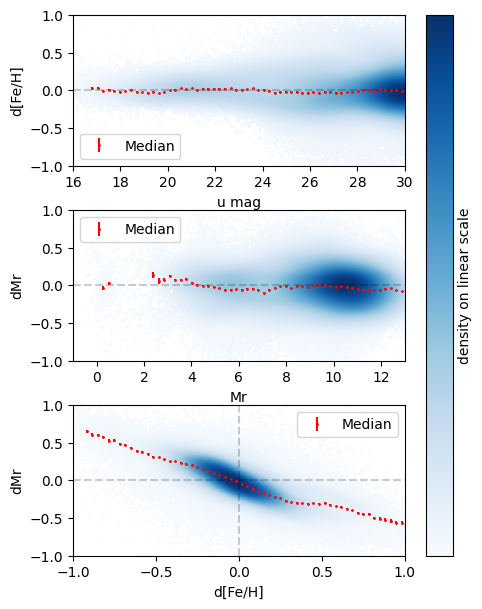

In [23]:
_ = misc_tools.plot_2D_multiple (x_test, p, y_test)
plt.savefig(img_path+"bias.png", bbox_inches='tight')

Histograms of estimated sigma


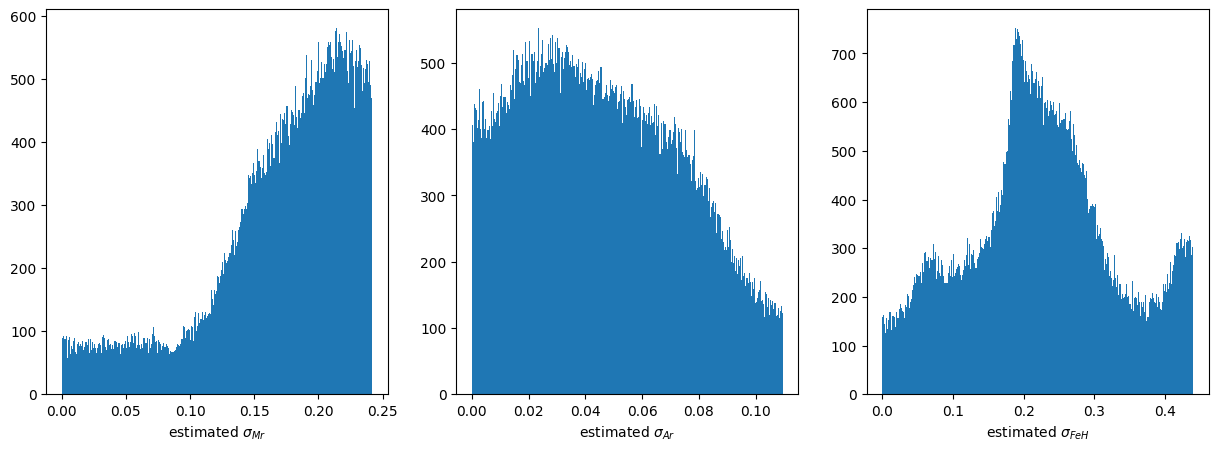

In [24]:
print ("Histograms of estimated sigma")
fig, ax = plt.subplots(1, 3, figsize=(3*5,5))
outputs = ["Mr", "Ar", "FeH"]
for i, name in enumerate(outputs):
    ax[i] = misc_tools.plot_sigma_histogram (ax[i], sigma_p[i], (sigma_p[i].min(), sigma_p[i].min()+3*tools.eval_tools.sigGzi(sigma_p[i])), name)

Histograms of expected N(0,1)


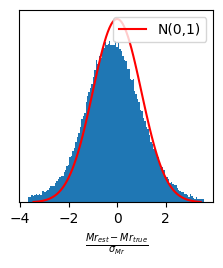

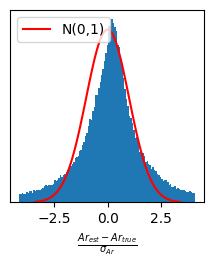

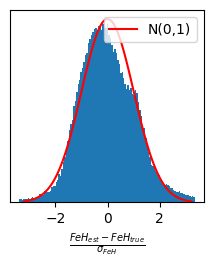

In [25]:
print ("Histograms of expected N(0,1)")
ax_1=[]
fig_1=[]
for i in range (3):
    fig, ax = plt.subplots(1, figsize=(2.5,2.5))
    ax_1.append(ax)
    fig_1.append(fig)
fig = misc_tools.plot_expected_gauss(p, sigma_p, y_test, outputs, ax_1, nbins=120)
names=["Mr", "Ar", "Fe/H"]
for i,fig in enumerate(fig_1):
    fig.savefig(img_path+names[i].replace("/","")+"_gauss.png", bbox_inches='tight')

In [26]:
mse = tf.keras.losses.MeanSquaredError()(y_test, p).numpy()

differences_sigma = [np.abs(y_test[i] - p[i])<sigma_p[i] for i in range (len (p))]
inside_sigma = [differences_sigma[i].sum() for i in range (len (p))]
inside_sigma.append(np.array (differences_sigma).all (axis=0).sum())
inside_sigma = np.array(inside_sigma) / p[0].shape[0]

differences_sigma_mse = [np.abs(y_test[i] - p[i])<sigma_p[i]+mse for i in range (len (p))]
inside_sigma_mse = [differences_sigma_mse[i].sum() for i in range (len (p))]
inside_sigma_mse.append(np.array (differences_sigma_mse).all (axis=0).sum())
inside_sigma_mse = np.array(inside_sigma_mse) / p[0].shape[0]

table = pd.DataFrame([inside_sigma, inside_sigma_mse], columns=["Mr (expect 0.68)", "Ar (expect 0.68)", "Fe/H (expect 0.68)", "All (expect 0.32)"],
                          index=["Percent inside est sigma", "Percent inside (est sigma + MSE)"])
print ("Table of coverage:")
display(table)

Table of coverage:


,Mr (expect 0.68),Ar (expect 0.68),Fe/H (expect 0.68),All (expect 0.32)
Percent inside est sigma,0.583135,0.519396,0.628995,0.249225
Percent inside (est sigma + MSE),0.710850,0.848870,0.765099,0.542159


/mnt/Storage/Projects/BEAST_LSST/Results/misc_tools.py:131: RuntimeWarning: invalid value encountered in scalar divide
  coverage = np.array([(np.abs(y_test[i][(y_test[i] >= bins[j]) & (y_test[i] <= bins[j + 1])] - p[i][


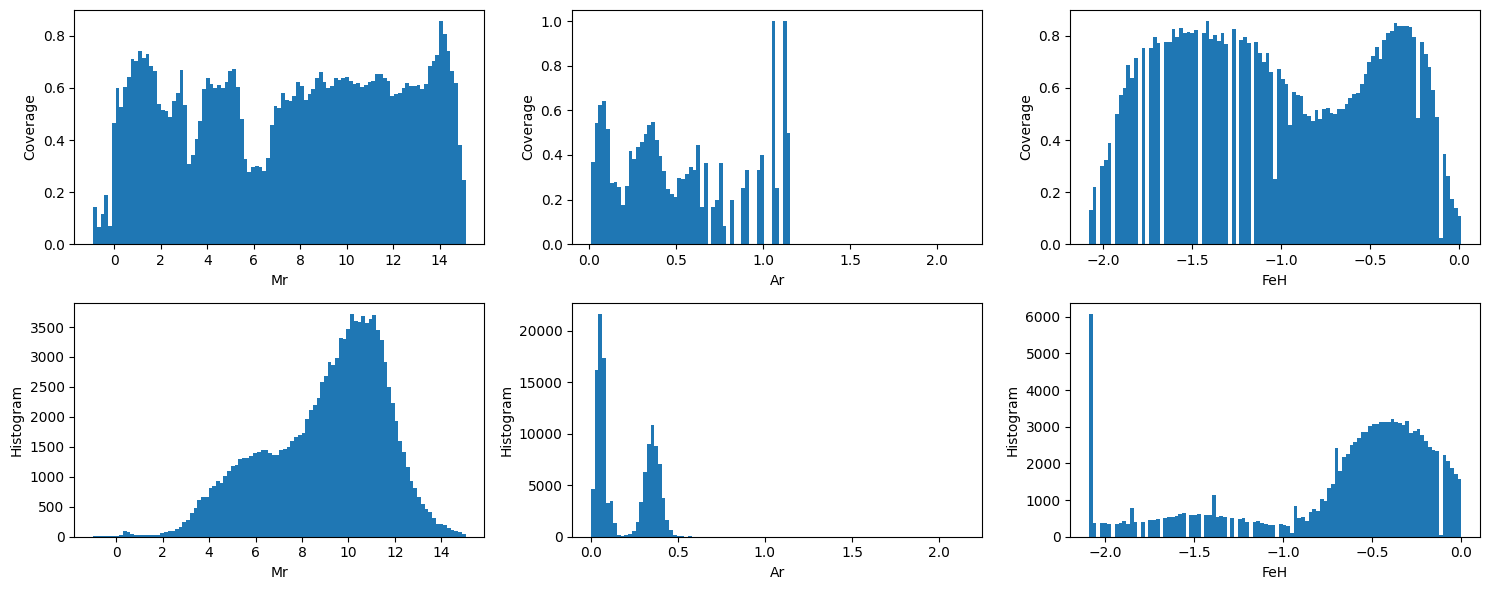

In [27]:
_ = misc_tools.plot_sigma_dependency(p, sigma_p, y_test)